In [664]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold,cross_val_score,GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [665]:
data=pd.read_csv("medical_cost.txt")
data=pd.DataFrame(data)
print(data)

    age   bmi  children smoker     region  medical_cost
0    19  27.9         0     no  southwest         16884
1    25  26.2         0     no  southeast          2721
2    30  32.5         1     no  southwest          4149
3    35  29.8         2     no  northwest          5003
4    40  31.2         1     no  southeast          6412
5    45  28.7         2    yes  southwest         20630
6    50  35.1         3     no  northeast         11150
7    52  30.5         2    yes  southeast         23890
8    55  33.2         1     no  northwest         12480
9    60  29.5         2     no  southwest         13220
10   22  24.8         0     no  northeast          2198
11   28  26.5         1     no  southeast          3766
12   33  30.2         0    yes  northwest         16210
13   38  34.1         2     no  southwest          5855
14   43  27.3         1     no  northeast          7260
15   48  36.4         3    yes  southeast         24560
16   53  31.8         2     no  northwest       

In [666]:
print(data.head())

   age   bmi  children smoker     region  medical_cost
0   19  27.9         0     no  southwest         16884
1   25  26.2         0     no  southeast          2721
2   30  32.5         1     no  southwest          4149
3   35  29.8         2     no  northwest          5003
4   40  31.2         1     no  southeast          6412


In [667]:
print(data.head(8))

   age   bmi  children smoker     region  medical_cost
0   19  27.9         0     no  southwest         16884
1   25  26.2         0     no  southeast          2721
2   30  32.5         1     no  southwest          4149
3   35  29.8         2     no  northwest          5003
4   40  31.2         1     no  southeast          6412
5   45  28.7         2    yes  southwest         20630
6   50  35.1         3     no  northeast         11150
7   52  30.5         2    yes  southeast         23890


In [668]:
print(data.head(len(data)))

    age   bmi  children smoker     region  medical_cost
0    19  27.9         0     no  southwest         16884
1    25  26.2         0     no  southeast          2721
2    30  32.5         1     no  southwest          4149
3    35  29.8         2     no  northwest          5003
4    40  31.2         1     no  southeast          6412
5    45  28.7         2    yes  southwest         20630
6    50  35.1         3     no  northeast         11150
7    52  30.5         2    yes  southeast         23890
8    55  33.2         1     no  northwest         12480
9    60  29.5         2     no  southwest         13220
10   22  24.8         0     no  northeast          2198
11   28  26.5         1     no  southeast          3766
12   33  30.2         0    yes  northwest         16210
13   38  34.1         2     no  southwest          5855
14   43  27.3         1     no  northeast          7260
15   48  36.4         3    yes  southeast         24560
16   53  31.8         2     no  northwest       

In [669]:
print(data.tail())

    age   bmi  children smoker     region  medical_cost
15   48  36.4         3    yes  southeast         24560
16   53  31.8         2     no  northwest         11890
17   57  29.1         0     no  southwest         10980
18   62  34.7         2    yes  northeast         26840
19   29  28.6         1     no  northwest          3925


In [670]:
print(data.tail(3))

    age   bmi  children smoker     region  medical_cost
17   57  29.1         0     no  southwest         10980
18   62  34.7         2    yes  northeast         26840
19   29  28.6         1     no  northwest          3925


In [671]:
print(data.shape)

(20, 6)


In [672]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           20 non-null     int64  
 1   bmi           20 non-null     float64
 2   children      20 non-null     int64  
 3   smoker        20 non-null     object 
 4   region        20 non-null     object 
 5   medical_cost  20 non-null     int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 1.1+ KB
None


In [673]:
print(data["age"])

0     19
1     25
2     30
3     35
4     40
5     45
6     50
7     52
8     55
9     60
10    22
11    28
12    33
13    38
14    43
15    48
16    53
17    57
18    62
19    29
Name: age, dtype: int64


In [674]:
print(data[["children","medical_cost"]])

    children  medical_cost
0          0         16884
1          0          2721
2          1          4149
3          2          5003
4          1          6412
5          2         20630
6          3         11150
7          2         23890
8          1         12480
9          2         13220
10         0          2198
11         1          3766
12         0         16210
13         2          5855
14         1          7260
15         3         24560
16         2         11890
17         0         10980
18         2         26840
19         1          3925


In [675]:
print(data.iloc[0])

age                    19
bmi                  27.9
children                0
smoker                 no
region          southwest
medical_cost        16884
Name: 0, dtype: object


In [676]:
print(data.iloc[:2])

   age   bmi  children smoker     region  medical_cost
0   19  27.9         0     no  southwest         16884
1   25  26.2         0     no  southeast          2721


In [677]:
print(data.describe())

             age        bmi   children  medical_cost
count  20.000000  20.000000  20.000000     20.000000
mean   41.200000  30.405000   1.300000  11501.150000
std    13.205262   3.197281   0.978721   7783.777106
min    19.000000  24.800000   0.000000   2198.000000
25%    29.750000  28.425000   0.750000   4789.500000
50%    41.500000  30.000000   1.000000  11065.000000
75%    52.250000  32.675000   2.000000  16378.500000
max    62.000000  36.400000   3.000000  26840.000000


In [678]:
print(data[data["bmi"]==27.9])

   age   bmi  children smoker     region  medical_cost
0   19  27.9         0     no  southwest         16884


In [679]:
print(data.isna())

      age    bmi  children  smoker  region  medical_cost
0   False  False     False   False   False         False
1   False  False     False   False   False         False
2   False  False     False   False   False         False
3   False  False     False   False   False         False
4   False  False     False   False   False         False
5   False  False     False   False   False         False
6   False  False     False   False   False         False
7   False  False     False   False   False         False
8   False  False     False   False   False         False
9   False  False     False   False   False         False
10  False  False     False   False   False         False
11  False  False     False   False   False         False
12  False  False     False   False   False         False
13  False  False     False   False   False         False
14  False  False     False   False   False         False
15  False  False     False   False   False         False
16  False  False     False   Fa

In [680]:
print(data.isna().sum())

age             0
bmi             0
children        0
smoker          0
region          0
medical_cost    0
dtype: int64


In [681]:
print(data.dropna())

    age   bmi  children smoker     region  medical_cost
0    19  27.9         0     no  southwest         16884
1    25  26.2         0     no  southeast          2721
2    30  32.5         1     no  southwest          4149
3    35  29.8         2     no  northwest          5003
4    40  31.2         1     no  southeast          6412
5    45  28.7         2    yes  southwest         20630
6    50  35.1         3     no  northeast         11150
7    52  30.5         2    yes  southeast         23890
8    55  33.2         1     no  northwest         12480
9    60  29.5         2     no  southwest         13220
10   22  24.8         0     no  northeast          2198
11   28  26.5         1     no  southeast          3766
12   33  30.2         0    yes  northwest         16210
13   38  34.1         2     no  southwest          5855
14   43  27.3         1     no  northeast          7260
15   48  36.4         3    yes  southeast         24560
16   53  31.8         2     no  northwest       

In [682]:
data=pd.DataFrame(data)
smoker=data["smoker"].map({
    "no":0,"yes":1})
data["smoker_encoded"]=smoker.values
print(data)
region=data["region"].map({
    "northeast":1,"southeast":2,"northwest":3,"southwest":4
})
data["region_encoded"]=region.values
print(data)

    age   bmi  children smoker     region  medical_cost  smoker_encoded
0    19  27.9         0     no  southwest         16884               0
1    25  26.2         0     no  southeast          2721               0
2    30  32.5         1     no  southwest          4149               0
3    35  29.8         2     no  northwest          5003               0
4    40  31.2         1     no  southeast          6412               0
5    45  28.7         2    yes  southwest         20630               1
6    50  35.1         3     no  northeast         11150               0
7    52  30.5         2    yes  southeast         23890               1
8    55  33.2         1     no  northwest         12480               0
9    60  29.5         2     no  southwest         13220               0
10   22  24.8         0     no  northeast          2198               0
11   28  26.5         1     no  southeast          3766               0
12   33  30.2         0    yes  northwest         16210         

In [683]:
data=data.drop(["smoker","region"],axis=1)
print(data)


    age   bmi  children  medical_cost  smoker_encoded  region_encoded
0    19  27.9         0         16884               0               4
1    25  26.2         0          2721               0               2
2    30  32.5         1          4149               0               4
3    35  29.8         2          5003               0               3
4    40  31.2         1          6412               0               2
5    45  28.7         2         20630               1               4
6    50  35.1         3         11150               0               1
7    52  30.5         2         23890               1               2
8    55  33.2         1         12480               0               3
9    60  29.5         2         13220               0               4
10   22  24.8         0          2198               0               1
11   28  26.5         1          3766               0               2
12   33  30.2         0         16210               1               3
13   38  34.1       

In [684]:
print("Dataset Splitting into A and B  :")
A=data.drop("medical_cost",axis=1)
B=data["medical_cost"]
print("A : \n",A,"\nShape of A :\n",A.shape)
print("B :\n",B,"\nShape of B :\n",B.shape)

Dataset Splitting into A and B  :
A : 
     age   bmi  children  smoker_encoded  region_encoded
0    19  27.9         0               0               4
1    25  26.2         0               0               2
2    30  32.5         1               0               4
3    35  29.8         2               0               3
4    40  31.2         1               0               2
5    45  28.7         2               1               4
6    50  35.1         3               0               1
7    52  30.5         2               1               2
8    55  33.2         1               0               3
9    60  29.5         2               0               4
10   22  24.8         0               0               1
11   28  26.5         1               0               2
12   33  30.2         0               1               3
13   38  34.1         2               0               4
14   43  27.3         1               0               1
15   48  36.4         3               1               2
16   53 

In [685]:
A_train,A_test,B_train,B_test=train_test_split(
    A,B,test_size=0.4,random_state=42)
print("Dataset features splitted into training and testing sets :")
print("A_train :\n",A_train,"\nShape of A_train :\n",A_train.shape)
print("A_test :\n",A_test,"\nShape of A_train :\n",A_test.shape)
print("B_train :\n",B_train,"\nShape of B_train :\n",B_train.shape)
print("B_test :\n",B_test,"\nShape of B_train :\n",B_test.shape)


Dataset features splitted into training and testing sets :
A_train :
     age   bmi  children  smoker_encoded  region_encoded
18   62  34.7         2               1               1
16   53  31.8         2               0               3
13   38  34.1         2               0               4
2    30  32.5         1               0               4
9    60  29.5         2               0               4
19   29  28.6         1               0               3
4    40  31.2         1               0               2
12   33  30.2         0               1               3
7    52  30.5         2               1               2
10   22  24.8         0               0               1
14   43  27.3         1               0               1
6    50  35.1         3               0               1 
Shape of A_train :
 (12, 5)
A_test :
     age   bmi  children  smoker_encoded  region_encoded
0    19  27.9         0               0               4
17   57  29.1         0               0            

In [686]:
print("Standardization : ")
scaler=StandardScaler()
A_train_scaled=scaler.fit_transform(A_train)
A_test_scaled=scaler.transform(A_test)
print("A_train_scaled :\n",A_train_scaled,"\nA_train_scaled Shape:\n",A_train_scaled.shape)
print("A_test_scaled :\n",A_test_scaled,"\nA_test_scaled Shape:\n",A_test_scaled.shape)

Standardization : 
A_train_scaled :
 [[ 1.57043805  1.30602238  0.67671554  1.73205081 -1.19316609]
 [ 0.83937206  0.3201313   0.67671554 -0.57735027  0.49130368]
 [-0.37907125  1.10204491  0.67671554 -0.57735027  1.33353857]
 [-1.02890769  0.55810501 -0.48336824 -0.57735027  1.33353857]
 [ 1.40797894 -0.46178232  0.67671554 -0.57735027  1.33353857]
 [-1.11013724 -0.76774851 -0.48336824 -0.57735027  0.49130368]
 [-0.21661214  0.11615383 -0.48336824 -0.57735027 -0.3509312 ]
 [-0.78521902 -0.22380861 -1.64345203  1.73205081  0.49130368]
 [ 0.75814251 -0.12181987  0.67671554  1.73205081 -0.3509312 ]
 [-1.67874412 -2.05960579 -1.64345203 -0.57735027 -1.19316609]
 [ 0.02707652 -1.20969969 -0.48336824 -0.57735027 -1.19316609]
 [ 0.5956834   1.44200735  1.83679933 -0.57735027 -1.19316609]] 
A_train_scaled Shape:
 (12, 5)
A_test_scaled :
 [[-1.92243278 -1.00572222 -1.64345203 -0.57735027  1.33353857]
 [ 1.16429028 -0.59776729 -1.64345203 -0.57735027  1.33353857]
 [ 0.43322429  1.88395853  1.83

In [687]:
print("Multiple Linear Regression :\n-------------------")
model1=LinearRegression()
print("The model fitting is done successfully!!-->")
print(model1.fit(A_train_scaled,B_train))
print("Predicted values by the Model 1 :")
B_pred=model1.predict(A_test_scaled)
print(B_pred)

Multiple Linear Regression :
-------------------
The model fitting is done successfully!!-->
LinearRegression()
Predicted values by the Model 1 :
[2.22142996e+00 1.05493390e+04 2.31296287e+04 2.13036289e+03
 1.06355338e+04 2.18883898e+04 3.89164245e+03 6.32765428e+03]


In [688]:
comparison1=pd.DataFrame({
    "Actual":B_test,
    "Predicted":B_pred})
print("Multiple Linear Regression comparison : \n",comparison1)

Multiple Linear Regression comparison : 
     Actual     Predicted
0    16884      2.221430
17   10980  10549.339008
15   24560  23129.628701
1     2721   2130.362892
8    12480  10635.533760
5    20630  21888.389784
11    3766   3891.642454
3     5003   6327.654282


In [689]:
print(" Evaluation of Multiple Linear Regression")
print("<---------------------------------------->")
mae=mean_absolute_error(B_test,B_pred)
mse=mean_squared_error(B_test,B_pred)
rmse=np.sqrt(mse)
r2=r2_score(B_test,B_pred)
print("MAE :",mae)
print("MSE :",mse)
print("RMSE :",rmse)
print("R2 :",r2)

 Evaluation of Multiple Linear Regression
<---------------------------------------->
MAE : 2985.825091077679
MSE : 36791353.296888374
RMSE : 6065.587629973568
R2 : 0.36026203953421476


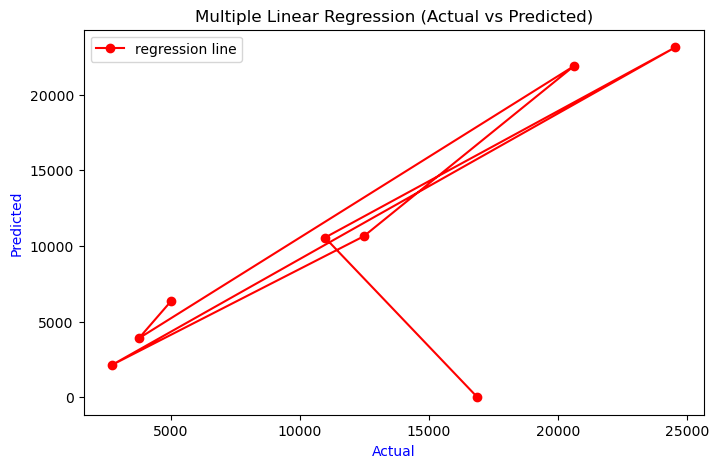

In [690]:
plt.figure(figsize=(8,5))
plt.plot(B_test,B_pred,marker="o",color="red",label="regression line")
plt.xlabel("Actual",color="blue")
plt.ylabel("Predicted",color="blue")
plt.title("Multiple Linear Regression (Actual vs Predicted)")
plt.legend()
plt.show()
          

In [691]:
print("  Simple Linear Regression ")
print("<[----------------------------]>")
print(data.info())

  Simple Linear Regression 
<[----------------------------]>
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             20 non-null     int64  
 1   bmi             20 non-null     float64
 2   children        20 non-null     int64  
 3   medical_cost    20 non-null     int64  
 4   smoker_encoded  20 non-null     int64  
 5   region_encoded  20 non-null     int64  
dtypes: float64(1), int64(5)
memory usage: 1.1 KB
None


In [692]:
X=data[["smoker_encoded"]]
y=data["medical_cost"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print("Simple Linear Regression : Feature splitting into training and testing .")
print("X :\n",X)
print("X_train :\n",X_train)
print("X_test :\n",X_test)
print("y :\n",y)
print("y :\n",y_train)
print("y :\n",y_test)



Simple Linear Regression : Feature splitting into training and testing .
X :
     smoker_encoded
0                0
1                0
2                0
3                0
4                0
5                1
6                0
7                1
8                0
9                0
10               0
11               0
12               1
13               0
14               0
15               1
16               0
17               0
18               1
19               0
X_train :
     smoker_encoded
8                0
5                1
11               0
3                0
18               1
16               0
13               0
2                0
9                0
19               0
4                0
12               1
7                1
10               0
14               0
6                0
X_test :
     smoker_encoded
0                0
17               0
15               1
1                0
y :
 0     16884
1      2721
2      4149
3      5003
4      6412
5     20630
6     1

In [693]:
print("Feature Scaling :")
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)
print("X_train_scaled",X_train_scaled)
print("X_test_scaled",X_test_scaled)

Feature Scaling :
X_train_scaled [[-0.57735027]
 [ 1.73205081]
 [-0.57735027]
 [-0.57735027]
 [ 1.73205081]
 [-0.57735027]
 [-0.57735027]
 [-0.57735027]
 [-0.57735027]
 [-0.57735027]
 [-0.57735027]
 [ 1.73205081]
 [ 1.73205081]
 [-0.57735027]
 [-0.57735027]
 [-0.57735027]]
X_test_scaled [[-0.57735027]
 [-0.57735027]
 [ 1.73205081]
 [-0.57735027]]


In [697]:
print("Simple Linear Regression model fitting is done: ")
print(model1.fit(X_train_scaled,y_train))

print("Simple Linear Regression model predicted values :")
y_pred=model1.predict(X_test_scaled)
print(y_pred)

Simple Linear Regression model fitting is done: 
LinearRegression()
Simple Linear Regression model predicted values :
[ 7275.66666667  7275.66666667 21892.5         7275.66666667]


In [695]:
print("Simple Linear Regression Comparison :")
comparison2=pd.DataFrame({
    "Actual":y_test,
    "Predicted":y_pred
    
})
print(comparison2)

Simple Linear Regression Comparison :
    Actual     Predicted
0    16884   7275.666667
17   10980   7275.666667
15   24560  21892.500000
1     2721   7275.666667


In [699]:
print("Simple Linear Regression Evaluation")
print("-----------------------------------")
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)
print("MAE :",mae)
print("MSE :",mse)
print("RMSE :",rmse)
print("R2 :",r2)

Simple Linear Regression Evaluation
-----------------------------------
MAE : 5133.708333333332
MSE : 33475674.895833332
RMSE : 5785.816700849875
R2 : 0.47691099161294437


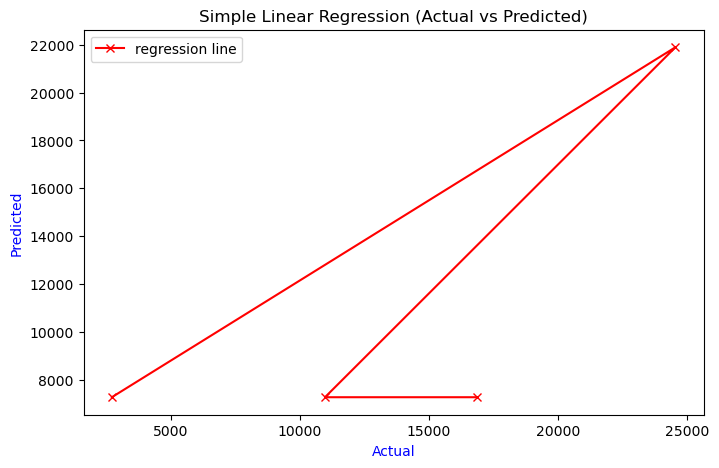

In [701]:
plt.figure(figsize=(8,5))
plt.plot(y_test,y_pred,marker="x",color="red",label="regression line")
plt.xlabel("Actual",color="blue")
plt.ylabel("Predicted",color="blue")
plt.title("Simple Linear Regression (Actual vs Predicted)")
plt.legend()
plt.show()
           

In [703]:
print("Polynomial Regression :")
print("-----------------------")
print("Polynomial Features fitted successfully!!")
poly=PolynomialFeatures()
A_train_poly=poly.fit_transform(A_train)
A_test_poly=poly.transform(A_test)
print("A_train_poly :\n",A_train_poly[:3])
print("A_test_poly :\n",A_test_poly[:3])
model3=LinearRegression()
model3.fit(A_train_poly,B_train)
B_poly_pred=model3.predict(A_test_poly)
print("Predicted Values of Polynomial Regression :")
print(B_poly_pred)

Polynomial Regression :
-----------------------
Polynomial Features fitted successfully!!
A_train_poly :
 [[1.00000e+00 6.20000e+01 3.47000e+01 2.00000e+00 1.00000e+00 1.00000e+00
  3.84400e+03 2.15140e+03 1.24000e+02 6.20000e+01 6.20000e+01 1.20409e+03
  6.94000e+01 3.47000e+01 3.47000e+01 4.00000e+00 2.00000e+00 2.00000e+00
  1.00000e+00 1.00000e+00 1.00000e+00]
 [1.00000e+00 5.30000e+01 3.18000e+01 2.00000e+00 0.00000e+00 3.00000e+00
  2.80900e+03 1.68540e+03 1.06000e+02 0.00000e+00 1.59000e+02 1.01124e+03
  6.36000e+01 0.00000e+00 9.54000e+01 4.00000e+00 0.00000e+00 6.00000e+00
  0.00000e+00 0.00000e+00 9.00000e+00]
 [1.00000e+00 3.80000e+01 3.41000e+01 2.00000e+00 0.00000e+00 4.00000e+00
  1.44400e+03 1.29580e+03 7.60000e+01 0.00000e+00 1.52000e+02 1.16281e+03
  6.82000e+01 0.00000e+00 1.36400e+02 4.00000e+00 0.00000e+00 8.00000e+00
  0.00000e+00 0.00000e+00 1.60000e+01]]
A_test_poly :
 [[1.00000e+00 1.90000e+01 2.79000e+01 0.00000e+00 0.00000e+00 4.00000e+00
  3.61000e+02 5.30100

In [705]:
print("Polynomial Regression Comparison")
comparison3=pd.DataFrame({
    "Actual":B_test,
    "Predicted":B_poly_pred
})
print(comparison3)

Polynomial Regression Comparison
    Actual     Predicted
0    16884   3732.483375
17   10980   3988.201804
15   24560  22368.899156
1     2721   3681.043944
8    12480   8919.821092
5    20630  21842.730110
11    3766   3381.437012
3     5003   5524.659811


In [707]:
print("Evaluation of Polynomial Regression : ")
print("------------------------------------- ")
mae=mean_absolute_error(B_test,B_pred)
mse=mean_squared_error(B_test,B_pred)
rmse=np.sqrt(mse)
r2=r2_score(B_test,B_pred)
print("MAE :",mae)
print("MSE :",mse)
print("RMSE :",rmse)
print("R2 :",r2)
      

Evaluation of Polynomial Regression : 
------------------------------------- 
MAE : 2985.825091077679
MSE : 36791353.296888374
RMSE : 6065.587629973568
R2 : 0.36026203953421476


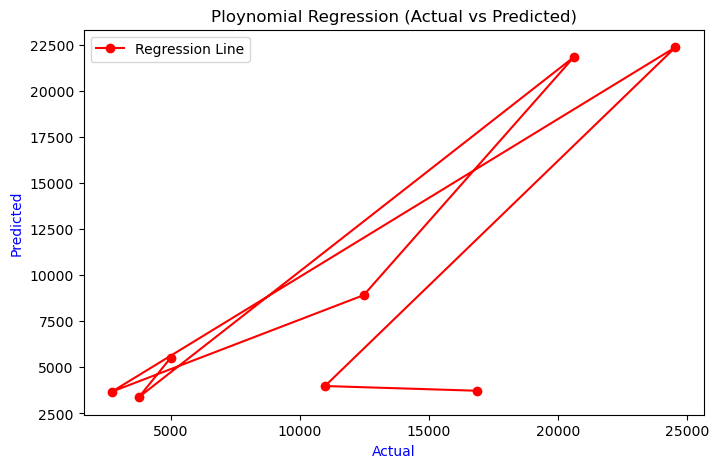

In [709]:
plt.figure(figsize=(8,5))
plt.plot(B_test,B_poly_pred,marker="o",color="red",label="Regression Line")
plt.xlabel("Actual",color="blue")
plt.ylabel("Predicted",color="blue")
plt.title("Ploynomial Regression (Actual vs Predicted)")
plt.legend()
plt.show()

In [711]:
from sklearn.svm import SVR
print(" Support Vector Regression")
print("<[----o--------------o----]>")
print("Basic SVR :")
svr_model=SVR(
    kernel='rbf',
    C=100,
    gamma="scale",
    epsilon=0.2)
print(svr_model.fit(A_train_scaled,B_train))
print("Model Fitting is done")
B_pred_svr=svr_model.predict(A_test_scaled)
print("Basic SVR model predicted values :",B_pred_svr)

 Support Vector Regression
<[----o--------------o----]>
Basic SVR :
SVR(C=100, epsilon=0.2)
Model Fitting is done
Basic SVR model predicted values : [9106.26343232 9210.07490997 9339.50364475 9030.78404524 9224.26137513
 9296.46817309 9000.69674548 9098.30097823]


In [713]:
print("BASIC SVR EVALUATION")
print("------------------------------------- ")
mae=mean_absolute_error(B_test,B_pred_svr)
mse=mean_squared_error(B_test,B_pred_svr)
rmse=np.sqrt(mse)
r2=r2_score(B_test,B_pred_svr)
print("MAE :",mae)
print("MSE :",mse)
print("RMSE :",rmse)
print("R2 :",r2)
      

BASIC SVR EVALUATION
------------------------------------- 
MAE : 6874.651279209171
MSE : 64790627.84031749
RMSE : 8049.262565000442
R2 : -0.12659688751835008


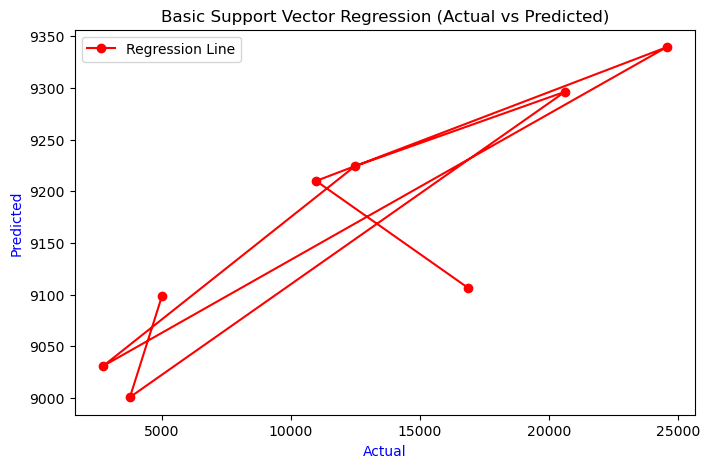

In [715]:
plt.figure(figsize=(8,5))
plt.plot(B_test,B_pred_svr,marker="o",color="red",label="Regression Line")
plt.xlabel("Actual",color="blue")
plt.ylabel("Predicted",color="blue")
plt.title("Basic Support Vector Regression (Actual vs Predicted)")
plt.legend()
plt.show()

In [717]:
comparison4=pd.DataFrame({
    "Actual":B_test,
    "Predicted":B_pred_svr 
})
print("Basic SVR (Actual vs Predicted)\n",comparison4)

Basic SVR (Actual vs Predicted)
     Actual    Predicted
0    16884  9106.263432
17   10980  9210.074910
15   24560  9339.503645
1     2721  9030.784045
8    12480  9224.261375
5    20630  9296.468173
11    3766  9000.696745
3     5003  9098.300978


In [719]:
print("Tuned Support Vector Regression")
print("-------------------------------")
kf=KFold(n_splits=5,
         shuffle=True,
         random_state=42)
svr_cv=SVR(
        kernel="rbf",
        epsilon=0.2,
        gamma="scale",
        C=100)
scores=cross_val_score(
    svr_cv,
    A_train_scaled,
    B_train,
    cv=kf,
    scoring="r2")
print("Tuned Scores :\n",scores)
grid={"C":[1,10,100,1000],
      "epsilon":[0.2,0.3,0.4,0.5],
      "gamma":[0.1,0.01,"scale"],
      "kernel":["rbf"]}
grid_search=GridSearchCV(
    estimator=SVR(),
    param_grid=grid,
    cv=5,
    scoring="r2",
    n_jobs=-1)
print(grid_search.fit(A_train_scaled,B_train))
tuned_svr=grid_search.best_estimator_
print("Model Fitting is done.")
print("Best Parameters :\n",grid_search.best_params_)
print("Best CV R2 :\n",grid_search.best_score_)
print("Best Estmator :",tuned_svr)
B_tuned=tuned_svr.predict(A_test_scaled)
print("Predicted values of Tuned SVR :\n",B_tuned)

Tuned Support Vector Regression
-------------------------------
Tuned Scores :
 [-1.15021639e-03  1.51356849e-02 -1.56165909e+02 -2.74981208e+01
 -2.96254989e+01]
GridSearchCV(cv=5, estimator=SVR(), n_jobs=-1,
             param_grid={'C': [1, 10, 100, 1000],
                         'epsilon': [0.2, 0.3, 0.4, 0.5],
                         'gamma': [0.1, 0.01, 'scale'], 'kernel': ['rbf']},
             scoring='r2')
Model Fitting is done.
Best Parameters :
 {'C': 1000, 'epsilon': 0.2, 'gamma': 0.1, 'kernel': 'rbf'}
Best CV R2 :
 -0.09450250547088049
Best Estmator : SVR(C=1000, epsilon=0.2, gamma=0.1)
Predicted values of Tuned SVR :
 [ 7530.92748556  8904.60661738 10895.96583368  7051.20050642
  9328.46010997 10090.33768653  7076.90198647  8195.17518056]


In [723]:
print("Evaluation of Tuned SVR (Actual vs Predicted)")
print("---------------------------------------------")
mae=mean_absolute_error(B_test,B_tuned)
mse=mean_squared_error(B_test,B_tuned)
rmse=np.sqrt(mse)
r2=r2_score(B_test,B_tuned)
print("MAE :",mae)
print("MSE :",mse)
print("RMSE :",rmse)
print("R2 :",r2)
      

Evaluation of Tuned SVR (Actual vs Predicted)
---------------------------------------------
MAE : 6202.122492542903
MSE : 54926553.62314617
RMSE : 7411.245079144675
R2 : 0.04492229174788309


In [725]:
print("Comparison of Tuned SVR (Actual vs Predicted)")

comparison5=pd.DataFrame({
    "Actual":B_test,
    "Predicted":B_tuned
    
})
print(comparison5)

Comparison of Tuned SVR (Actual vs Predicted)
    Actual     Predicted
0    16884   7530.927486
17   10980   8904.606617
15   24560  10895.965834
1     2721   7051.200506
8    12480   9328.460110
5    20630  10090.337687
11    3766   7076.901986
3     5003   8195.175181


In [727]:
final_comparison=pd.DataFrame({
    "Actual":B_test,
    "Predicted":B_pred_svr,
    "Tuned":B_tuned
})
print(final_comparison)

    Actual    Predicted         Tuned
0    16884  9106.263432   7530.927486
17   10980  9210.074910   8904.606617
15   24560  9339.503645  10895.965834
1     2721  9030.784045   7051.200506
8    12480  9224.261375   9328.460110
5    20630  9296.468173  10090.337687
11    3766  9000.696745   7076.901986
3     5003  9098.300978   8195.175181
